# Diabetes Prediction: Model Validation and Saving
Starting from the model comparison in `modeling.ipynb`, this notebook:
1. Rebuilds the same train/test split
2. Selects the best model from the cross-validation results
3. Tunes its hyperparameters (training data only)
4. Chooses the decision threshold (training data only)
5. Evaluates once on the held-out test set
6. Explains the model with feature importnace
7. Saves teh Final Model

In [1]:
# Import libraries
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, RandomizedSearchCV,
                                     cross_val_predict, ParameterGrid)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_recall_curve, roc_curve, confusion_matrix,
                             ConfusionMatrixDisplay, recall_score, precision_score,
                             f1_score, roc_auc_score, average_precision_score,
                             accuracy_score, classification_report)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
os.makedirs('../../images', exist_ok=True)
os.makedirs('../../reports', exist_ok=True)
os.makedirs('../../models', exist_ok=True)

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Data and Recreate the Split

In [2]:
# Load the cleaned dataset
DATA_PATH = '../../data/cleaned_1.csv'
TARGET = 'diabetes'

df = pd.read_csv(DATA_PATH)

X = df.drop(columns=TARGET)
y = df[TARGET]

# Same split settings as modeling.ipynb (same random_state), so the training
# and test sets are exactly the same rows as before
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')
print(f'Diabetic rate  train: {y_train.mean():.3f}  test: {y_test.mean():.3f}')

Train: (76731, 8)  Test: (19183, 8)
Diabetic rate  train: 0.088  test: 0.088


In [3]:
# Column groups (from the cleaned dataset)
NUM_COLS = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
BIN_COLS = ['hypertension', 'heart_disease']
CAT_COLS = ['gender', 'smoking_history']

assert set(NUM_COLS + BIN_COLS + CAT_COLS) == set(X_train.columns), 'Column mismatch'

# Scale numbers, one-hot encode text, keep 0/1 columns as they are
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('bin', 'passthrough', BIN_COLS),
])

# Cross-validation: 5 folds, class ratio kept in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Ratio of negatives to positives, used by XGBoost
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


def make_models(strategy):
    """Return the four models configured for the given imbalance strategy."""
    cw = 'balanced' if strategy == 'class_weight' else None
    spw = pos_weight if strategy == 'class_weight' else 1
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, class_weight=cw),
        'Random Forest': RandomForestClassifier(n_estimators=200, class_weight=cw,
                                                random_state=RANDOM_STATE),
        'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.1, scale_pos_weight=spw,
                                 eval_metric='logloss', random_state=RANDOM_STATE),
        'LightGBM': LGBMClassifier(n_estimators=300, class_weight=cw,
                                   random_state=RANDOM_STATE, verbose=-1),
    }


def build_pipeline(model, strategy):
    """Preprocessing (and SMOTE if chosen) are refit inside every CV fold."""
    if strategy == 'smote':
        return ImbPipeline([('prep', preprocessor),
                            ('smote', SMOTE(random_state=RANDOM_STATE)),
                            ('model', model)])
    return Pipeline([('prep', preprocessor), ('model', model)])

## 2. Selecting the Best Model

In [4]:
# Read the comparison table saved by modeling.ipynb
RESULTS_PATH = '../../reports/model_comparison.csv'
assert os.path.exists(RESULTS_PATH), 'Run modeling.ipynb first so model_comparison.csv exists'

results_df = pd.read_csv(RESULTS_PATH)

# Rank all real models by PR-AUC (the baseline is excluded)
candidates = (results_df[results_df['model'] != 'Dummy (baseline)']
              .sort_values('pr_auc', ascending=False)
              .reset_index(drop=True))
print('Top 3 by PR-AUC (cross-validation on the training set):')
display(candidates.head(3))

best_row = candidates.iloc[0]
BEST_MODEL_NAME = best_row['model']
BEST_STRATEGY = best_row['strategy']

# To choose a different row yourself, uncomment and edit these two lines:
# BEST_MODEL_NAME, BEST_STRATEGY = 'XGBoost', 'none'

print(f"\nSelected: {BEST_MODEL_NAME} with strategy '{BEST_STRATEGY}'")

Top 3 by PR-AUC (cross-validation on the training set):


,model,strategy,recall,precision,f1,roc_auc,pr_auc
0,XGBoost,none,0.691,0.956,0.802,0.977,0.881
1,XGBoost,smote,0.700,0.935,0.801,0.977,0.880
2,XGBoost,class_weight,0.879,0.527,0.659,0.976,0.880



Selected: XGBoost with strategy 'none'


## 3. Hyperparameter Tuning

A random search tries 15 different settings of the selected model using
5-fold cross-validation on the training set and keeps the best one.

In [5]:
# Settings to search for each model
param_grids = {
    'Logistic Regression': {'model__C': [0.01, 0.1, 1, 10, 100]},
    'Random Forest': {'model__n_estimators': [200, 400],
                      'model__max_depth': [None, 10, 20],
                      'model__min_samples_leaf': [1, 2, 5]},
    'XGBoost': {'model__n_estimators': [200, 400, 600],
                'model__max_depth': [3, 4, 6],
                'model__learning_rate': [0.03, 0.05, 0.1],
                'model__subsample': [0.8, 1.0],
                'model__colsample_bytree': [0.8, 1.0]},
    'LightGBM': {'model__n_estimators': [200, 400, 600],
                 'model__num_leaves': [15, 31, 63],
                 'model__learning_rate': [0.03, 0.05, 0.1],
                 'model__min_child_samples': [20, 50, 100]},
}

grid = param_grids[BEST_MODEL_NAME]
n_iter = min(15, len(ParameterGrid(grid)))

best_pipeline = build_pipeline(make_models(BEST_STRATEGY)[BEST_MODEL_NAME], BEST_STRATEGY)

# This can take 5 to 15 minutes
search = RandomizedSearchCV(best_pipeline, grid, n_iter=n_iter,
                            scoring='average_precision', cv=cv,
                            n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
search.fit(X_train, y_train)

print('Best settings :', search.best_params_)
print(f"PR-AUC before tuning: {best_row['pr_auc']:.3f}")
print(f'PR-AUC after tuning : {search.best_score_:.3f}')

# The best pipeline, already refit on the full training set
final_pipeline = search.best_estimator_

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best settings : {'model__subsample': 0.8, 'model__n_estimators': 600, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}
PR-AUC before tuning: 0.881
PR-AUC after tuning : 0.889


## 4. Decision Threshold

By default a patient is called diabetic when the predicted probability is at
least 0.5. Here the cutoff is chosen using cross-validated predictions on the
training set, so the test set stays untouched. The chosen cutoff maximises F1.

Chosen threshold: 0.489  (default is 0.5)


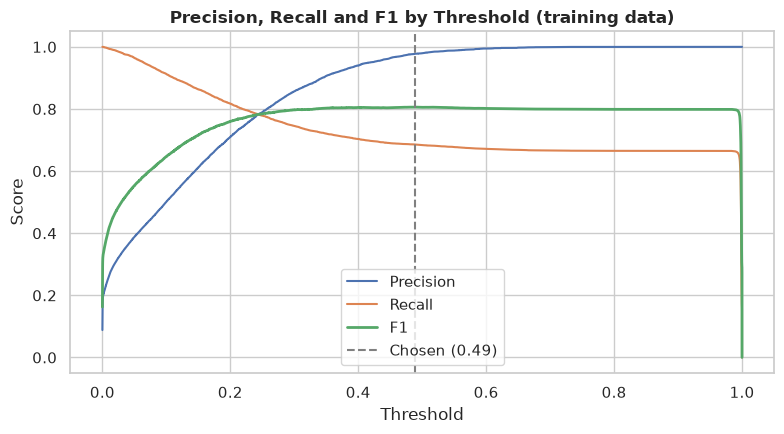

In [6]:
# Out-of-fold probabilities: each training row is predicted by a model that never saw it
oof_proba = cross_val_predict(final_pipeline, X_train, y_train, cv=cv,
                              method='predict_proba', n_jobs=-1)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof_proba)
f1_curve = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)

# Cutoff with the best F1
best_threshold = float(thr[f1_curve.argmax()])

# Alternative for screening: the highest cutoff that still keeps 90% recall
# best_threshold = float(thr[np.where(rec[:-1] >= 0.90)[0].max()])

print(f'Chosen threshold: {best_threshold:.3f}  (default is 0.5)')

plt.figure(figsize=(8, 4.5))
plt.plot(thr, prec[:-1], label='Precision')
plt.plot(thr, rec[:-1], label='Recall')
plt.plot(thr, f1_curve, label='F1', linewidth=2)
plt.axvline(best_threshold, color='gray', linestyle='--', label=f'Chosen ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1 by Threshold (training data)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../../images/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Final Evaluation on the Test Set

The 20% test set is used here for the first and only time.

In [7]:
# Predicted probabilities on the held-out test set
test_proba = final_pipeline.predict_proba(X_test)[:, 1]


def score(name, threshold):
    """Scores at a given cutoff."""
    pred = (test_proba >= threshold).astype(int)
    return {'setting': name, 'threshold': round(threshold, 3),
            'recall': recall_score(y_test, pred),
            'precision': precision_score(y_test, pred),
            'f1': f1_score(y_test, pred),
            'accuracy': accuracy_score(y_test, pred)}


final_results = pd.DataFrame([score('Default cutoff', 0.5),
                              score('Tuned cutoff', best_threshold)]).round(3)
display(final_results)

test_roc = roc_auc_score(y_test, test_proba)
test_pr = average_precision_score(y_test, test_proba)
print(f'ROC-AUC: {test_roc:.3f}   PR-AUC: {test_pr:.3f}')
print(f'PR-AUC in cross-validation was {search.best_score_:.3f}. '
      'A small gap means the model is not overfitted.')

y_pred = (test_proba >= best_threshold).astype(int)
print('\nClassification report (tuned cutoff):')
print(classification_report(y_test, y_pred, target_names=['No diabetes', 'Diabetes']))

,setting,threshold,recall,precision,f1,accuracy
0,Default cutoff,0.500,0.694,0.975,0.811,0.971
1,Tuned cutoff,0.489,0.695,0.973,0.810,0.971


ROC-AUC: 0.978   PR-AUC: 0.887
PR-AUC in cross-validation was 0.889. A small gap means the model is not overfitted.

Classification report (tuned cutoff):
              precision    recall  f1-score   support

 No diabetes       0.97      1.00      0.98     17487
    Diabetes       0.97      0.69      0.81      1696

    accuracy                           0.97     19183
   macro avg       0.97      0.85      0.90     19183
weighted avg       0.97      0.97      0.97     19183



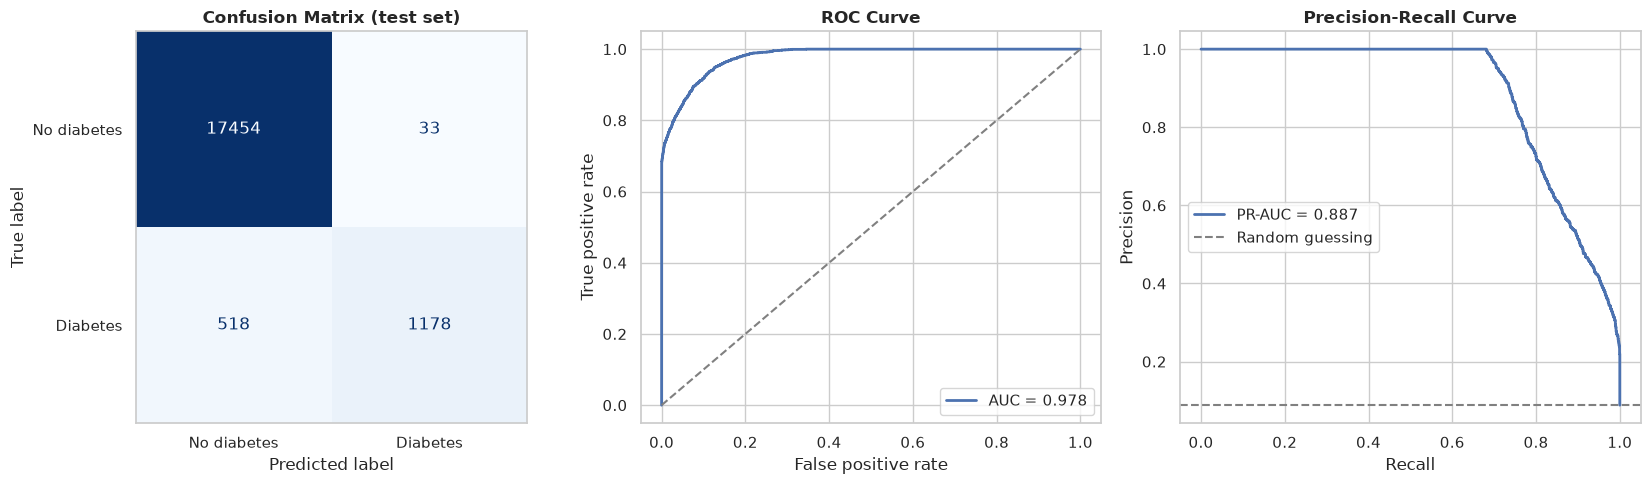

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['No diabetes', 'Diabetes']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].grid(False)
axes[0].set_title('Confusion Matrix (test set)', fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC = {test_roc:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

# Precision-recall curve
p_curve, r_curve, _ = precision_recall_curve(y_test, test_proba)
axes[2].plot(r_curve, p_curve, linewidth=2, label=f'PR-AUC = {test_pr:.3f}')
axes[2].axhline(y_test.mean(), linestyle='--', color='gray', label='Random guessing')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('../../images/final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Importance

Permutation importance shuffles one column at a time and measures how much
the PR-AUC drops. A large drop means the model relies on that column.

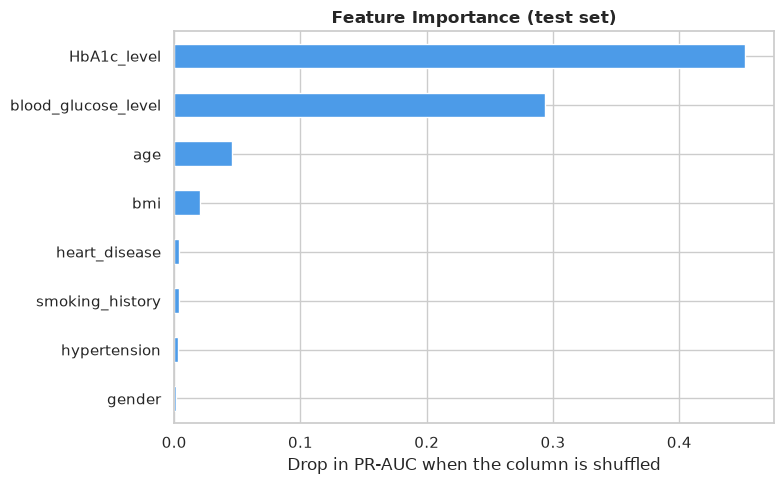

In [9]:
perm = permutation_importance(final_pipeline, X_test, y_test,
                              scoring='average_precision', n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=-1)

importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values()

plt.figure(figsize=(8, 5))
importance.plot.barh(color='#4C9BE8')
plt.xlabel('Drop in PR-AUC when the column is shuffled')
plt.title('Feature Importance (test set)', fontweight='bold')
plt.tight_layout()
plt.savefig('../../images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save the Model

In [10]:
# Save the full pipeline (preprocessing + model) with its chosen cutoff
artifact = {
    'pipeline': final_pipeline,
    'threshold': best_threshold,
    'features': list(X_train.columns),
    'model_name': BEST_MODEL_NAME,
    'strategy': BEST_STRATEGY,
}
joblib.dump(artifact, '../../models/best_model.pkl')

# Save the final scores for the report
final_results.to_csv('../../reports/final_results.csv', index=False)

size_mb = os.path.getsize('../../models/best_model.pkl') / 1e6
print(f'Saved models/best_model.pkl ({size_mb:.1f} MB)')

# Test: reload the model and predict for a new patient
loaded = joblib.load('../../models/best_model.pkl')
new_patient = pd.DataFrame([{
    'gender': 'Female', 'age': 54.0, 'hypertension': 0, 'heart_disease': 0,
    'smoking_history': 'never', 'bmi': 27.3,
    'HbA1c_level': 6.8, 'blood_glucose_level': 160,
}])[loaded['features']]

risk = loaded['pipeline'].predict_proba(new_patient)[0, 1]
label = 'Diabetic' if risk >= loaded['threshold'] else 'Not diabetic'
print(f'Predicted risk: {risk:.2f}  ->  {label}')

Saved models/best_model.pkl (0.6 MB)
Predicted risk: 1.00  ->  Diabetic


## 8. Conclusions

- **Best model:** (model name) with (strategy), chosen by PR-AUC in cross-validation.
- **Tuning:** PR-AUC moved from (before) to (after).
- **Test performance:** recall (x), precision (x), F1 (x), ROC-AUC (x).
- **Generalisation:** test PR-AUC is close to the cross-validation PR-AUC, so the model is not overfitted.
- **Main drivers:** HbA1c level and blood glucose level (see feature importance).
- **Limitation:** the diabetes label follows clear thresholds on HbA1c and glucose,
  so scores are likely higher than they would be on real patients.
- **Use:** this is a screening aid, not a diagnosis.